# Week 2 — Feed-Forward Neural Network & Hyperparameter Experimentation

## Internship Project

This notebook implements a Feed-Forward Neural Network (FNN) using PyTorch for CIFAR-10 image classification.

It also investigates the effect of different hyperparameters on model performance.

### Objectives

- Implement a Feed-Forward Neural Network using PyTorch.
- Train and evaluate the model on CIFAR-10.
- Experiment with different learning rates and batch sizes.
- Compare the resulting model performance.
- Document the experimental results.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. PyTorch and Device Configuration

PyTorch is used as the deep learning framework for implementing and training the neural network.

The model is executed on the available device. Since this project is being developed without GPU support, CPU execution is used.

In [2]:
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

device = torch.device("cpu")

print("Using device:", device)

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu
Using device: cpu


## 2. CIFAR-10 Dataset

The CIFAR-10 dataset is used for image classification.

It contains 32 × 32 RGB images belonging to 10 different classes.

The classes are:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

In [4]:
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

## 3. Data Preprocessing

The images are converted into PyTorch tensors and normalized before being provided to the neural network.

Normalization helps keep the input values within a suitable range for neural network training.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [6]:
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 170M/170M [24:45<00:00, 115kB/s]


Training samples: 50000
Testing samples: 10000


## 4. DataLoader

A DataLoader divides the dataset into batches and provides the data to the neural network during training.

The batch size determines how many images are processed before the model updates its weights.

In [7]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch size:", batch_size)

Batch size: 64


In [8]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])


## 5. Feed-Forward Neural Network

The FNN processes each image as a flattened vector.

Since each CIFAR-10 image has dimensions 32 × 32 × 3, the input contains:

32 × 32 × 3 = 3072 features.

The architecture used is:

Input (3072)
↓
Fully Connected Layer (128)
↓
ReLU
↓
Fully Connected Layer (64)
↓
ReLU
↓
Output Layer (10)

In [9]:
class FeedForwardNN(nn.Module):

    def __init__(self):
        super(FeedForwardNN, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32 * 32 * 3, 128)

        self.fc2 = nn.Linear(128, 64)

        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [10]:
fnn_model = FeedForwardNN().to(device)

print(fnn_model)

FeedForwardNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


## 6. Loss Function and Optimizer

Cross-Entropy Loss is used because CIFAR-10 is a multi-class classification problem.

The Adam optimizer is used to update the model parameters during training.

The initial learning rate is set to 0.001.

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    fnn_model.parameters(),
    lr=0.001
)

In [12]:
num_epochs = 3

fnn_train_losses = []
fnn_train_accuracies = []

for epoch in range(num_epochs):

    fnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = fnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)

    epoch_accuracy = 100 * correct / total

    fnn_train_losses.append(epoch_loss)
    fnn_train_accuracies.append(epoch_accuracy)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/3] Loss: 1.6518 Accuracy: 41.51%
Epoch [2/3] Loss: 1.4553 Accuracy: 48.78%
Epoch [3/3] Loss: 1.3612 Accuracy: 52.05%


In [13]:
fnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = fnn_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

fnn_test_accuracy = 100 * correct / total

print(f"FNN Test Accuracy: {fnn_test_accuracy:.2f}%")

FNN Test Accuracy: 50.42%


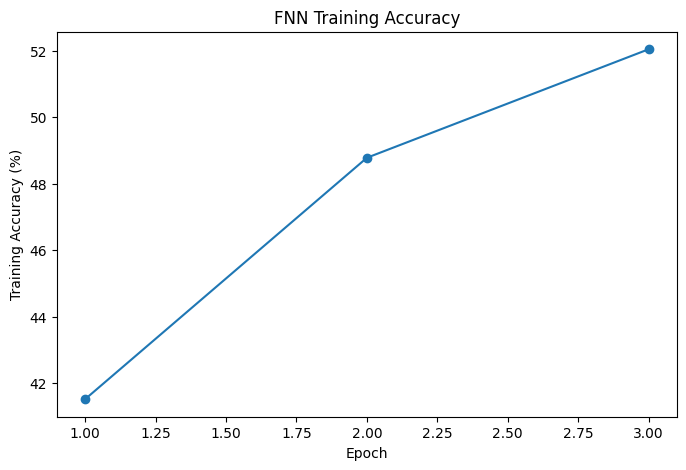

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    fnn_train_accuracies,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("FNN Training Accuracy")

plt.show()

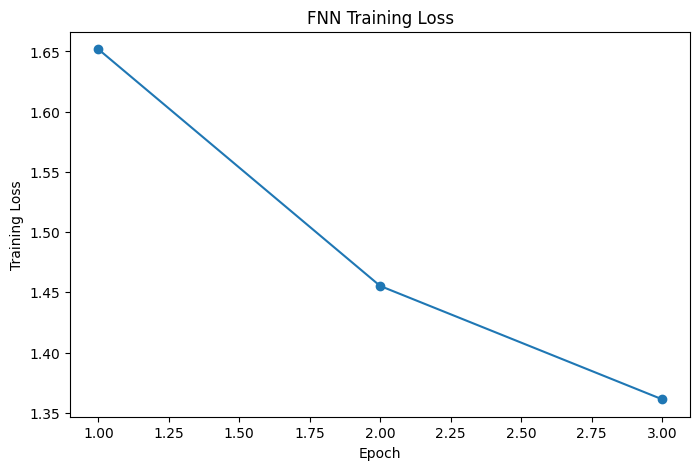

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    fnn_train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("FNN Training Loss")

plt.show()